Contesto del Progetto

Il problema delle fake news è diventato una minaccia significativa nel mondo moderno, alimentato dalla crescente diffusione dei social media e dalla velocità con cui le informazioni possono viaggiare. Questo fenomeno ha portato a disinformazione diffusa e ha creato problemi nella società e nelle istituzioni.

Il Governo degli Stati Uniti, consapevole di questa sfida, ha deciso di prendere provvedimenti concreti. Ha incaricato la tua azienda di sviluppare un plug-in per Chrome in grado di identificare se una notizia è falsa o veritiera. Il sistema avrà lo scopo di proteggere gli utenti dalla disinformazione, migliorando la qualità delle informazioni online.

Obiettivo del Progetto

L'obiettivo è sviluppare un modello di Machine Learning che possa rilevare le fake news con precisione.

Valore Aggiunto

Il sistema di rilevamento delle fake news avrà un impatto significativo a livello sociale, garantendo:

Riduzione della disinformazione: aiutando gli utenti a identificare tempestivamente notizie non attendibili.
Miglioramento della fiducia nei media: fornendo strumenti tecnologici avanzati per contrastare il problema della disinformazione.
Supporto decisionale: utenti e istituzioni potranno prendere decisioni basate su informazioni più affidabili.
Fasi del Progetto

Analisi dei Dati: Verranno analizzati due dataset forniti (link: https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip):

Notizie Vere
Notizie False
Alcune delle domande chiave da esplorare:

Le fake news sono più frequenti in una determinata categoria?
Esistono argomenti che sono più soggetti alle fake news?
I titoli delle fake news presentano dei pattern ricorrenti?
Addestramento del Modello:

Il modello sarà sviluppato utilizzando tecniche di Natural Language Processing (NLP) e Machine Learning.
Verrà addestrato con i dataset di notizie vere e false per riconoscere i pattern testuali associati a notizie non veritiere.
Si analizzeranno le caratteristiche rilevanti, come titoli, parole chiave e categorie di notizie.
Validazione e Ottimizzazione:

Si utilizzeranno metriche di performance (es. accuracy, precision, recall) per valutare l’efficacia del modello.
Saranno applicate tecniche di ottimizzazione per migliorare la capacità di riconoscimento delle fake news.

Download ed estrazione del dataset.

In [1]:
import requests
import zipfile
import os

# Define the URL of the zip file
zip_url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip"

# Define the path where the zip file will be downloaded
zip_file_path = "fake_news.zip"

# Define the directory where the contents will be extracted
extraction_path = "./fake_news_data"

# Download the zip file
print(f"Downloading {zip_url}...")
response = requests.get(zip_url)
with open(zip_file_path, "wb") as f:
    f.write(response.content)
print("Download complete.")

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the contents
print(f"Extracting {zip_file_path} to {extraction_path}...")
with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
    zip_ref.extractall(extraction_path)
print("Extraction complete.")

print(f"Contents of {extraction_path}:")
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        print(os.path.join(root, file))

Download complete.
Extracting fake_news.zip to ./fake_news_data...
Extraction complete.
Contents of ./fake_news_data:
./fake_news_data/True.csv
./fake_news_data/Fake.csv


Caricamento dei dataset 'True.csv' e 'Fake.csv' in due DataFrame di pandas distinti (`df_true` e `df_fake`). Assegniamo un'etichetta (`label`) numerica a ciascun tipo di notizia (0 per le notizie vere, 1 per le notizie false). Successivamente, concateniamo questi due DataFrame in un unico `df_combined`.

In [2]:
import pandas as pd

# Define paths for the datasets
true_news_path = os.path.join(extraction_path, 'True.csv')
fake_news_path = os.path.join(extraction_path, 'Fake.csv')

# Load True.csv and assign label 0
df_true = pd.read_csv(true_news_path)
df_true['label'] = 0
print(f"Loaded True.csv with shape: {df_true.shape}")

# Load Fake.csv and assign label 1
df_fake = pd.read_csv(fake_news_path)
df_fake['label'] = 1
print(f"Loaded Fake.csv with shape: {df_fake.shape}")

# Concatenate both DataFrames
df_combined = pd.concat([df_true, df_fake], ignore_index=True)
print("Concatenated both DataFrames.")

# Display the first 5 rows of the combined DataFrame
print("\nFirst 5 rows of the combined DataFrame:")
print(df_combined.head())

# Print the shape of the combined DataFrame
print("\nShape of the combined DataFrame:")
print(df_combined.shape)

Loaded True.csv with shape: (21417, 5)
Loaded Fake.csv with shape: (23481, 5)
Concatenated both DataFrames.

First 5 rows of the combined DataFrame:
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       0  
1  December 29, 2017       0  


Visualizziamo la distribuzione delle notizie vere e false attraverso diverse categorie. Raggruppa i dati in base alla colonna 'subject' e 'label'.

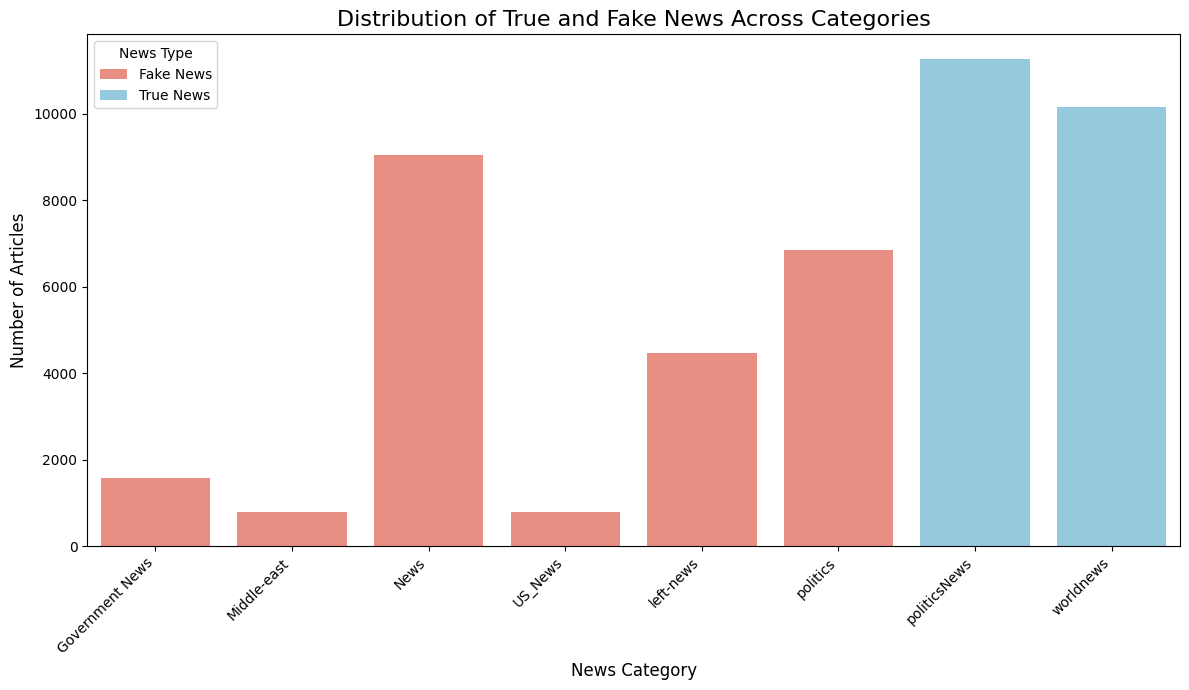

Category Counts for True and Fake News:
           subject  label  count label_name
0  Government News      1   1570  Fake News
1      Middle-east      1    778  Fake News
2             News      1   9050  Fake News
3          US_News      1    783  Fake News
4        left-news      1   4459  Fake News
5         politics      1   6841  Fake News
6     politicsNews      0  11272  True News
7        worldnews      0  10145  True News


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'subject' and 'label' and count occurrences
category_counts = df_combined.groupby(['subject', 'label']).size().reset_index(name='count')

# Rename labels for better readability in the plot
category_counts['label_name'] = category_counts['label'].map({0: 'True News', 1: 'Fake News'})

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(data=category_counts, x='subject', y='count', hue='label_name', palette={'True News': 'skyblue', 'Fake News': 'salmon'})

plt.title('Distribution of True and Fake News Across Categories', fontsize=16)
plt.xlabel('News Category', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='News Type')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Print the grouped data for inspection
print("Category Counts for True and Fake News:")
print(category_counts)

Qui separiamo il DataFrame combinato `df_combined` in due nuovi DataFrame: `df_true_news` contenente solo le notizie vere (label 0) e `df_fake_news` contenente solo le notizie false (label 1).

In [4]:
df_true_news = df_combined[df_combined['label'] == 0].copy()
df_fake_news = df_combined[df_combined['label'] == 1].copy()

print(f"Shape of df_true_news: {df_true_news.shape}")
print(f"Shape of df_fake_news: {df_fake_news.shape}")

Shape of df_true_news: (21417, 5)
Shape of df_fake_news: (23481, 5)


In questa fase, creiamo una nuova colonna chiamata `full_text` sia per `df_true_news` che per `df_fake_news`. Questa colonna è la concatenazione dei campi 'title' e 'text' di ciascuna notizia. L'obiettivo è avere un unico campo di testo su cui applicare le tecniche di NLP

In [5]:
df_true_news['full_text'] = df_true_news['title'] + ' ' + df_true_news['text']
df_fake_news['full_text'] = df_fake_news['title'] + ' ' + df_fake_news['text']

print("Created 'full_text' column for df_true_news.")
print("Created 'full_text' column for df_fake_news.")

print("\nFirst 5 rows of df_true_news with 'full_text':")
print(df_true_news[['title', 'text', 'full_text']].head())

print("\nFirst 5 rows of df_fake_news with 'full_text':")
print(df_fake_news[['title', 'text', 'full_text']].head())

Created 'full_text' column for df_true_news.
Created 'full_text' column for df_fake_news.

First 5 rows of df_true_news with 'full_text':
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text  \
0  WASHINGTON (Reuters) - The head of a conservat...   
1  WASHINGTON (Reuters) - Transgender people will...   
2  WASHINGTON (Reuters) - The special counsel inv...   
3  WASHINGTON (Reuters) - Trump campaign adviser ...   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...   

                                           full_text  
0  As U.S. budget fight looms, Republicans flip t...  
1  U.S. military to accept transgender recruits o...  
2  Senior U.S. Republic

Funzione di data cleaning: lowercase, rimozione punteggiatura, numeri e stop words e le parole lemmatizzate, rendendo il testo pronto per analisi più avanzate. Testo pulito: (`processed_text`)

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet
import pandas as pd # Ensure pandas is imported for pd.isna

# Scarica solo ciò che serve
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True) # FIXED: Changed from 'averaged_perceptron_tagger'
nltk.download('punkt', quiet=True) # Added punkt for word_tokenize
nltk.download('punkt_tab', quiet=True) # Added to fix the LookupError for punkt_tab

# Inizializza lemmatizer e stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Funzione per convertire i tag di POS di NLTK in quelli di WordNet
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Funzione di preprocess veloce con POS
def preprocess_text_fast_pos(text):
    """
    - lowercase
    - rimuove numeri e punteggiatura
    - rimuove stopwords
    - lemmatizza usando POS leggero
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenizza usando nltk.word_tokenize per maggiore precisione
    tokens = word_tokenize(text)

    # POS tagging
    pos_tags = pos_tag(tokens)

    # Rimuovi stopwords e lemmatizza
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(pos))
              for word, pos in pos_tags if word not in stop_words]

    return ' '.join(tokens)

# Applicazione veloce sui dataset
df_true_news['processed_text'] = df_true_news['full_text'].apply(preprocess_text_fast_pos)
df_fake_news['processed_text'] = df_fake_news['full_text'].apply(preprocess_text_fast_pos)

# Controllo
print("\nEsempio df_true_news:")
print(df_true_news[['full_text', 'processed_text']].head())

print("\nEsempio df_fake_news:")
print(df_fake_news[['full_text', 'processed_text']].head())


Esempio df_true_news:
                                           full_text  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                      processed_text  
0  u budget fight loom republican flip fiscal scr...  
1  u military accept transgender recruit monday p...  
2  senior u republican senator let mr mueller job...  
3  fbi russia probe help australian diplomat tip ...  
4  trump want postal service charge much amazon s...  

Esempio df_fake_news:
                                               full_text  \
21417   Donald Trump Sends Out Embarrassing New Year’...   
21418   Drunk Bragging Trump Staffer Started Russian ...   
21419   Sheriff David Clarke Becomes An Internet Joke...   
21420   Trump Is So Obsessed He Even Has Obama’

Estrazione delle parole chiave utilizzando il metodo TF-IDF per le notizie vere e false. Inizializziamo un `TfidfVectorizer` per ciascun tipo di notizia, lo addestriamo sul testo pre-elaborato e calcoliamo i punteggi TF-IDF per ogni parola. Infine, mostriamo le 20 parole chiave con il punteggio TF-IDF più alto per ciascun dataset, rivelando i termini più distintivi per notizie vere e false.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd # Ensure pandas is imported as it's used directly here

# Initialize TfidfVectorizer for true news
tfidf_vectorizer_true = TfidfVectorizer(max_features=5000, max_df=0.9, min_df=5)

# Fit and transform the 'processed_text' column of df_true_news
tfidf_matrix_true = tfidf_vectorizer_true.fit_transform(df_true_news['processed_text'])

# Extract feature names for true news
feature_names_true = tfidf_vectorizer_true.get_feature_names_out()

# Calculate the sum of TF-IDF scores for each word across all true news documents
# Convert the sparse matrix to a dense array using .A1
scores_true = tfidf_matrix_true.sum(axis=0).A1

# Create a DataFrame for true news keywords
keywords_df_true = pd.DataFrame({'tfidf_score': scores_true}, index=feature_names_true)
keywords_df_true = keywords_df_true.sort_values(by='tfidf_score', ascending=False)

print("\nTop 20 Keywords for True News:")
print(keywords_df_true.head(20))

# Initialize TfidfVectorizer for fake news
tfidf_vectorizer_fake = TfidfVectorizer(max_features=5000, max_df=0.9, min_df=5)

# Fit and transform the 'processed_text' column of df_fake_news
tfidf_matrix_fake = tfidf_vectorizer_fake.fit_transform(df_fake_news['processed_text'])

# Extract feature names for fake news
feature_names_fake = tfidf_vectorizer_fake.get_feature_names_out()

# Calculate the sum of TF-IDF scores for each word across all fake news documents
# Convert the sparse matrix to a dense array using .A1
scores_fake = tfidf_matrix_fake.sum(axis=0).A1

# Create a DataFrame for fake news keywords
keywords_df_fake = pd.DataFrame({'tfidf_score': scores_fake}, index=feature_names_fake)
keywords_df_fake = keywords_df_fake.sort_values(by='tfidf_score', ascending=False)

print("\nTop 20 Keywords for Fake News:")
print(keywords_df_fake.head(20))


Top 20 Keywords for True News:
            tfidf_score
trump       1209.274066
state        655.489522
president    540.278814
republican   535.607002
would        530.238775
house        494.315207
government   422.032218
year         404.108387
party        388.900895
election     377.948837
new          371.038776
north        362.262932
united       361.669445
tax          353.388904
official     346.376062
russia       345.511468
korea        344.532816
court        343.187392
clinton      340.461140
vote         339.837646

Top 20 Keywords for Fake News:
            tfidf_score
trump       1745.372387
say          813.602648
president    602.111719
clinton      593.871090
obama        578.573107
video        566.235683
hillary      544.595627
people       510.413771
state        477.358085
go           472.367973
one          446.363149
make         443.445923
donald       442.283783
get          438.039917
would        432.288750
republican   421.321187
american     398.671771


Questi sono i primi 20 termini con il punteggio TF-IDF più alto per le notizie vere e false. Possiamo notare che le parole chiave per le notizie vere tendono a essere più formali e legate alla politica (`state`, `president`, `republican`), mentre le fake news mostrano un maggiore focus su `trump`, `clinton`, `obama` e termini più sensazionalistici come `video`.

Visualizziamo le stesse parole chiave TF-IDF estratte contando l'occorrenza in un barchart.

/tmp/ipython-input-1391786708.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-1391786708.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


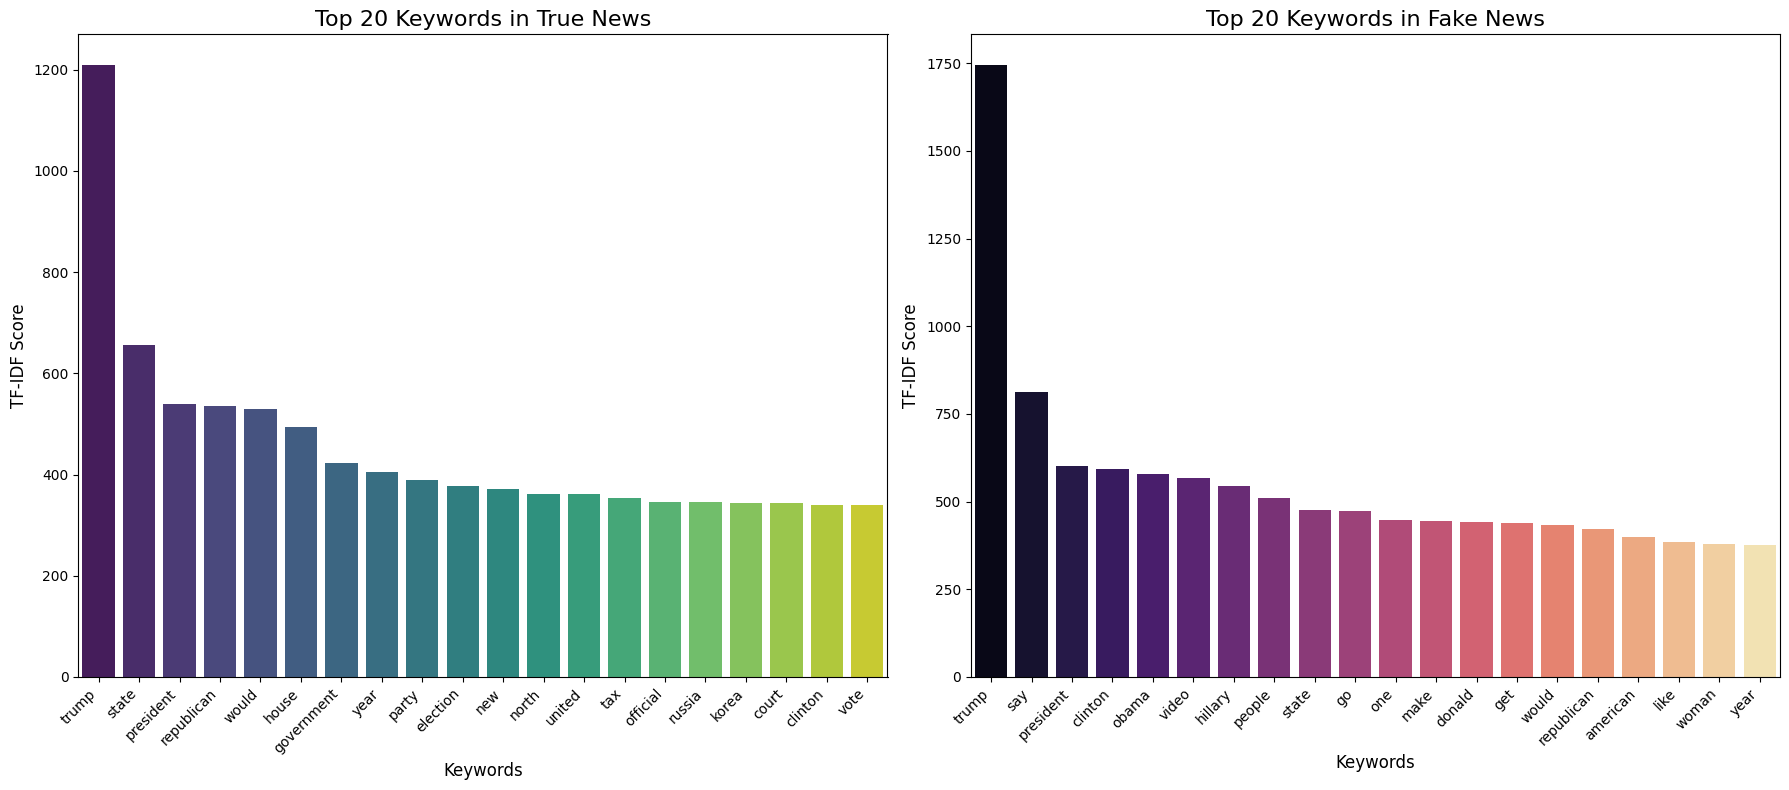

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for true and fake news keywords
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot for True News keywords
sns.barplot(x=keywords_df_true.head(20).index, y=keywords_df_true.head(20)['tfidf_score'], ax=axes[0], palette='viridis', hue=keywords_df_true.head(20).index, legend=False)
axes[0].set_title('Top 20 Keywords in True News', fontsize=16)
axes[0].set_xlabel('Keywords', fontsize=12)
axes[0].set_ylabel('TF-IDF Score', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot for Fake News keywords
sns.barplot(x=keywords_df_fake.head(20).index, y=keywords_df_fake.head(20)['tfidf_score'], ax=axes[1], palette='magma', hue=keywords_df_fake.head(20).index, legend=False)
axes[1].set_title('Top 20 Keywords in Fake News', fontsize=16)
axes[1].set_xlabel('Keywords', fontsize=12)
axes[1].set_ylabel('TF-IDF Score', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Analisi degli N-grammi (sequenze di parole) sui titoli delle notizie vere e false. Viene definita una funzione `get_top_ngrams` che estrae gli N-grammi più frequenti utilizzando `CountVectorizer`. Vengono poi calcolati e visualizzati i top 10 bigrammi (sequenze di due parole) e trigrammi (sequenze di tre parole) per entrambi i tipi di notizie, mostrando i risultati in tabelle e grafici a barre. Questa analisi aiuta a identificare pattern ricorrenti nelle frasi dei titoli.

Top 10 Bigrams in True News Titles:
           ngram  frequency
0    white house        790
1    north korea        720
2     trump says        362
3       trump to        312
4  islamic state        251
5  supreme court        235
6        says he        210
7        to meet        183
8          to be        180
9    puerto rico        178

Top 10 Bigrams in Fake News Titles:
             ngram  frequency
0     donald trump        805
1  president trump        487
2  hillary clinton        410
3           of the        373
4           in the        352
5      white house        348
6         trump is        318
7         fox news        314
8           on the        296
9            to be        295


/tmp/ipython-input-3643891766.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3643891766.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


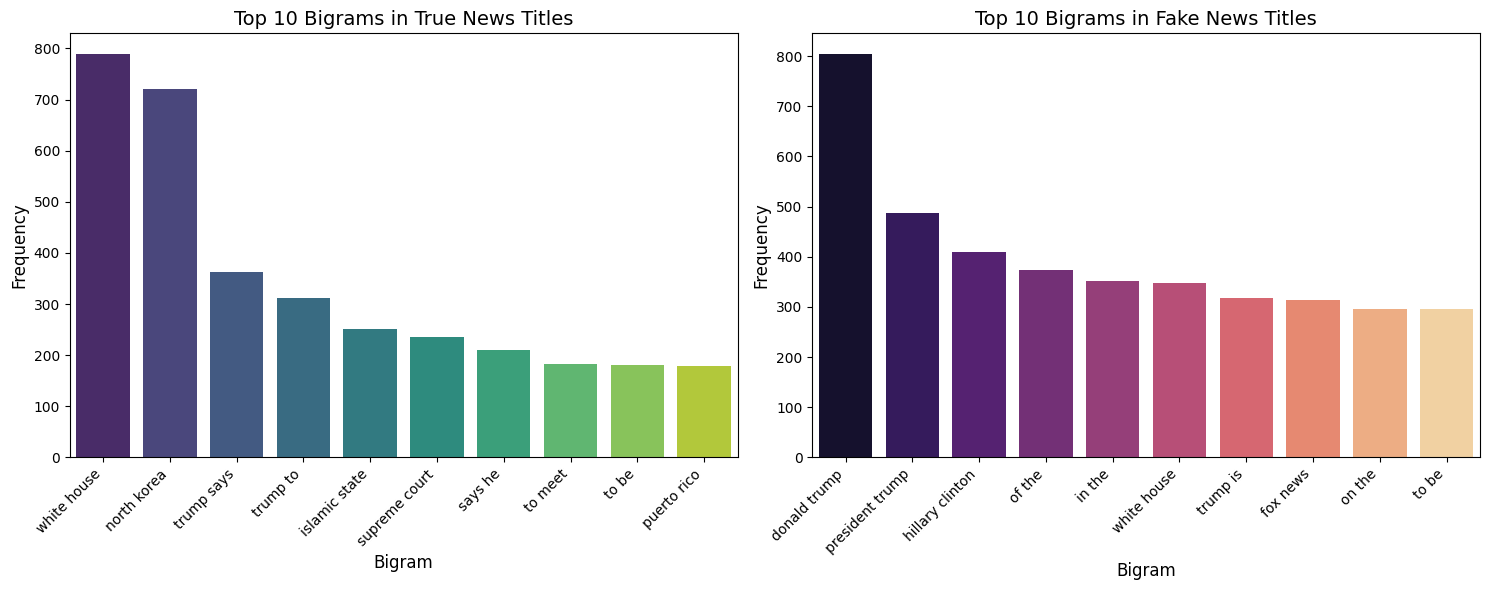


Top 10 Trigrams in True News Titles:
                  ngram  frequency
0        on north korea        137
1      trump on twitter        100
2         trump says he         94
3      white house says         86
4    house speaker ryan         76
5      factbox trump on         72
6     iran nuclear deal         70
7   trump presidency on         63
8  the trump presidency         62
9      trump travel ban         59

Top 10 Trigrams in Fake News Titles:
                ngram  frequency
0  black lives matter        160
1      boiler room ep        138
2     the white house         94
3     you won believe         75
4     on social media         53
5      new york times         51
6         to vote for         49
7         in front of         48
8     donald trump jr         47
9       fox news host         47


/tmp/ipython-input-3643891766.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3643891766.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


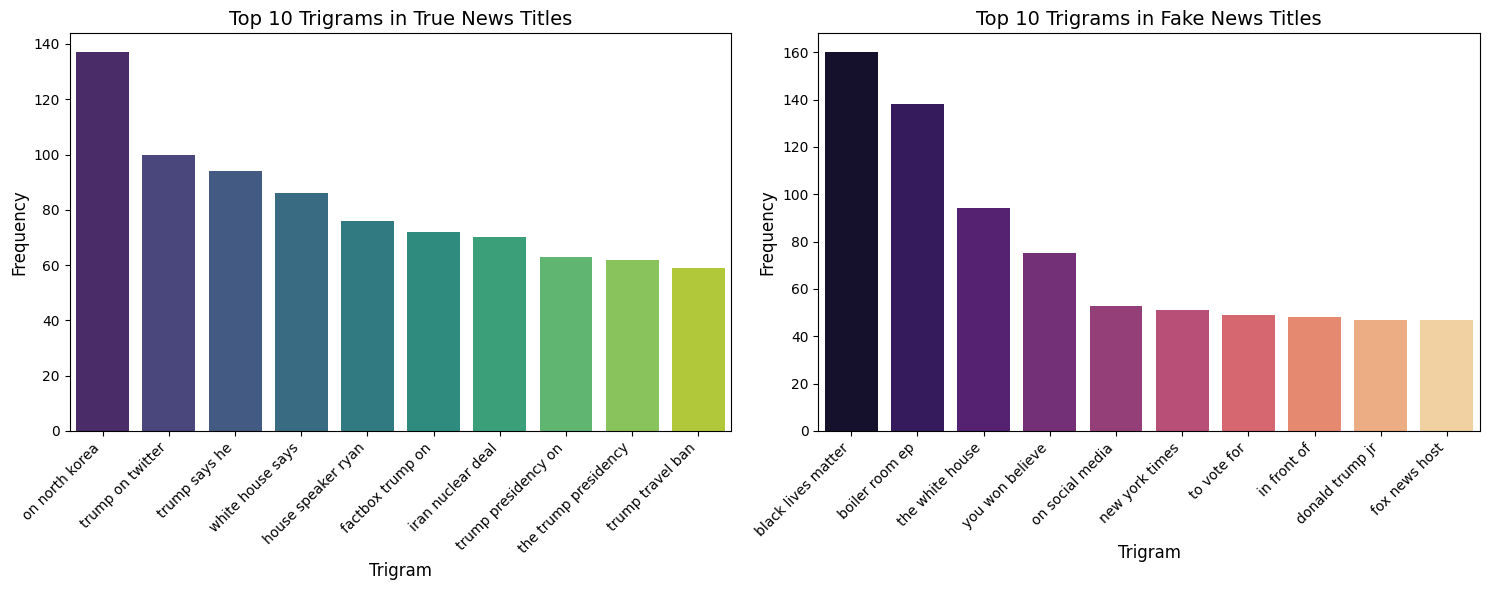

In [9]:
#EDA: estrae gli n grammi su testo non pulito e pieno di stopwords (la fase di EDA la facciamo sul dataset non pulito)

from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_top_ngrams(corpus, n=2, top_k=10):
    """Extracts the top_k n-grams from a given corpus."""
    vectorizer = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vectorizer.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_k], columns=['ngram', 'frequency'])

# Get top 10 bigrams for true news titles
true_bigrams_df = get_top_ngrams(df_true_news['title'], n=2, top_k=10)
print("Top 10 Bigrams in True News Titles:")
print(true_bigrams_df)

# Get top 10 bigrams for fake news titles
fake_bigrams_df = get_top_ngrams(df_fake_news['title'], n=2, top_k=10)
print("\nTop 10 Bigrams in Fake News Titles:")
print(fake_bigrams_df)

# Create subplots for comparing true and fake news bigrams
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for True News Bigrams
sns.barplot(x='ngram', y='frequency', data=true_bigrams_df, ax=axes[0], palette='viridis', hue='ngram', legend=False)
axes[0].set_title('Top 10 Bigrams in True News Titles', fontsize=14)
axes[0].set_xlabel('Bigram', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot for Fake News Bigrams
sns.barplot(x='ngram', y='frequency', data=fake_bigrams_df, ax=axes[1], palette='magma', hue='ngram', legend=False)
axes[1].set_title('Top 10 Bigrams in Fake News Titles', fontsize=14)
axes[1].set_xlabel('Bigram', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Get top 10 trigrams for true news titles
true_trigrams_df = get_top_ngrams(df_true_news['title'], n=3, top_k=10)
print("\nTop 10 Trigrams in True News Titles:")
print(true_trigrams_df)

# Get top 10 trigrams for fake news titles
fake_trigrams_df = get_top_ngrams(df_fake_news['title'], n=3, top_k=10)
print("\nTop 10 Trigrams in Fake News Titles:")
print(fake_trigrams_df)

# Create subplots for comparing true and fake news trigrams
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for True News Trigrams
sns.barplot(x='ngram', y='frequency', data=true_trigrams_df, ax=axes[0], palette='viridis', hue='ngram', legend=False)
axes[0].set_title('Top 10 Trigrams in True News Titles', fontsize=14)
axes[0].set_xlabel('Trigram', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot for Fake News Trigrams
sns.barplot(x='ngram', y='frequency', data=fake_trigrams_df, ax=axes[1], palette='magma', hue='ngram', legend=False)
axes[1].set_title('Top 10 Trigrams in Fake News Titles', fontsize=14)
axes[1].set_xlabel('Trigram', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

L'analisi degli N-grammi sui titoli rivela le sequenze di parole più frequenti. Per le notizie vere, vediamo combinazioni come 'white house' e 'north korea', che indicano argomenti politici e geopolitici standard. Per le fake news, emergono espressioni più dirette e talvolta sensazionalistiche come 'donald trump', 'president trump', e 'black lives matter', suggerendo pattern narrativi diversi.

Preparazione dei dati pre-elaborati per il *Topic Modeling* utilizzando Gensim.

In [10]:
# Preparare i dati per Topic Modeling
!pip install gensim
import gensim
import gensim.corpora as corpora
from gensim.models import LdaMulticore

# Tokenize the processed text for true news
data_words_true = [doc.split() for doc in df_true_news['processed_text']]
print(f"Tokenized {len(data_words_true)} true news documents.")

# Create Dictionary for true news
id2word_true = corpora.Dictionary(data_words_true)

# Create Corpus (Bag of Words) for true news
corpus_true = [id2word_true.doc2bow(doc) for doc in data_words_true]
print("Created dictionary and corpus for true news.")

# Tokenize the processed text for fake news
data_words_fake = [doc.split() for doc in df_fake_news['processed_text']]
print(f"Tokenized {len(data_words_fake)} fake news documents.")

# Create Dictionary for fake news
id2word_fake = corpora.Dictionary(data_words_fake)

# Create Corpus (Bag of Words) for fake news
corpus_fake = [id2word_fake.doc2bow(doc) for doc in data_words_fake]
print("Created dictionary and corpus for fake news.")

print("Example of true news corpus entry:")
print(corpus_true[:1][0])

print("Example of fake news corpus entry:")
print(corpus_fake[:1][0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.1 MB/s eta 0:00:00
Tokenized 21417 true news documents.
Created dictionary and corpus for true news.
Tokenized 23481 fake news documents.
Created dictionary and corpus for fake news.
Example of true news corpus entry:
[(0, 1), (1, 1), (2, 2), (3, 1), (4, 3), (5, 1), (6, 1), (7, 3), (8, 2), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 2), (19, 3), (20, 2), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 6), (27, 1), (28, 2), (29, 1), (30, 1), (31, 3), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 2), (40, 2), (41, 3), (42, 2), (43, 1), (44, 1), (45, 1), (46, 3), (47, 3), (48, 2), (49, 1), (50, 1), (51, 3), (52, 2), (53, 1), (54, 3), (55, 1), (56, 1), (57, 4), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 3), (64, 1), (65, 1), (66, 1), (67, 2), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1), (75, 2), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (8

Questa cella stampa le prime 20 righe della colonna `processed_text` per `df_true_news` e `df_fake_news`. Questo fornisce un'ulteriore verifica visiva della qualità della pre-elaborazione del testo, assicurandosi che la rimozione delle stop words e la lemmatizzazione siano avvenute correttamente prima di procedere con il topic modeling.

In [11]:
print(df_true_news['processed_text'].head(20))
print(df_fake_news['processed_text'].head(20))

0     u budget fight loom republican flip fiscal scr...
1     u military accept transgender recruit monday p...
2     senior u republican senator let mr mueller job...
3     fbi russia probe help australian diplomat tip ...
4     trump want postal service charge much amazon s...
5     white house congress prepare talk spending imm...
6     trump say russia probe fair timeline unclear n...
7     factbox trump twitter dec approval rating amaz...
8     trump twitter dec global warm following statem...
9     alabama official certify senator elect jones t...
10    jones certify u senate winner despite moore ch...
11    new york governor question constitutionality f...
12    factbox trump twitter dec vanity fair hillary ...
13    trump twitter dec trump iraq syria following s...
14    man say deliver manure mnuchin protest new u t...
15    virginia official postpone lottery draw decide...
16    u lawmaker question businessman trump tower me...
17    trump twitter dec hillary clinton tax cut 

Questa cella mostra un estratto delle parole presenti nei dizionari (`id2word_true.token2id.keys()`, `id2word_fake.token2id.keys()`) creati per le notizie vere e false rispettivamente.

In [12]:
print(id2word_true.token2id.keys())
print(id2word_fake.token2id.keys())

dict_keys(['action', 'add', 'administration', 'agree', 'aid', 'aide', 'already', 'also', 'among', 'approach', 'approve', 'arrival', 'assist', 'assistance', 'back', 'balloon', 'battle', 'begin', 'big', 'bill', 'billion', 'boost', 'border', 'borrow', 'brace', 'bring', 'budget', 'california', 'call', 'campaign', 'caucus', 'cbs', 'chairman', 'change', 'child', 'childhood', 'clean', 'clear', 'come', 'congress', 'congressional', 'conservative', 'control', 'corporation', 'country', 'create', 'crowley', 'cut', 'daca', 'date', 'debbie', 'debt', 'december', 'defend', 'defense', 'deferred', 'deficit', 'democrat', 'democratic', 'democrats', 'deportation', 'dingell', 'disable', 'discretionary', 'discuss', 'donald', 'draw', 'dreamer', 'early', 'economy', 'education', 'elderly', 'election', 'emergency', 'enough', 'entitlement', 'environmental', 'even', 'eventually', 'ever', 'exceed', 'exchange', 'expansion', 'expect', 'expiration', 'face', 'faction', 'far', 'favor', 'federal', 'fight', 'finance', 'fi

In questa cella, addestriamo due modelli LDA (Latent Dirichlet Allocation) distinti: uno per le notizie vere (`lda_model_true`) e uno per le notizie false (`lda_model_fake`). Il *topic modeling* mira a scoprire argomenti astratti che si verificano in una collezione di documenti. Vengono poi stampati i top 5 argomenti e le parole chiave associate per ciascun tipo di notizia.

In [13]:
num_topics = 5 # Number of topics for initial exploration

# Train LDA model for true news
print(f"Training LDA model for true news with {num_topics} topics...")
lda_model_true = LdaMulticore(corpus=corpus_true, id2word=id2word_true, num_topics=num_topics, workers=2, passes=10, chunksize=1000, random_state=100)
print("LDA model for true news training complete.")

# Print the topics for true news
print("\nTop topics for True News:")
for idx, topic in lda_model_true.print_topics():
    print(f"Topic #{idx}: {topic}")

# Train LDA model for fake news
print(f"\nTraining LDA model for fake news with {num_topics} topics...")
lda_model_fake = LdaMulticore(corpus=corpus_fake, id2word=id2word_fake, num_topics=num_topics, workers=2, passes=10, chunksize=1000, random_state=100)
print("LDA model for fake news training complete.")

# Print the topics for fake news
print("\nTop topics for Fake News:")
for idx, topic in lda_model_fake.print_topics():
    print(f"Topic #{idx}: {topic}")

Training LDA model for true news with 5 topics...
LDA model for true news training complete.

Top topics for True News:
Topic #0: 0.028*"say" + 0.016*"u" + 0.012*"state" + 0.009*"north" + 0.007*"united" + 0.007*"korea" + 0.007*"china" + 0.006*"reuters" + 0.005*"president" + 0.005*"minister"
Topic #1: 0.025*"say" + 0.008*"people" + 0.007*"reuters" + 0.007*"year" + 0.006*"police" + 0.006*"government" + 0.004*"party" + 0.004*"kill" + 0.004*"two" + 0.004*"right"
Topic #2: 0.019*"say" + 0.014*"court" + 0.013*"u" + 0.011*"state" + 0.010*"law" + 0.006*"would" + 0.006*"department" + 0.006*"rule" + 0.006*"case" + 0.005*"president"
Topic #3: 0.017*"say" + 0.011*"would" + 0.009*"party" + 0.009*"percent" + 0.008*"year" + 0.007*"government" + 0.006*"new" + 0.005*"tax" + 0.005*"million" + 0.005*"election"
Topic #4: 0.039*"trump" + 0.024*"say" + 0.017*"republican" + 0.012*"u" + 0.011*"house" + 0.011*"president" + 0.009*"clinton" + 0.009*"campaign" + 0.008*"election" + 0.007*"white"

Training LDA mode

I modelli LDA hanno identificato 5 topic principali per le notizie vere e 5 per le notizie false. Per le notizie vere, i topic sembrano ruotare attorno a politica internazionale (`north korea`, `china`), legislazione (`court`, `law`), e questioni economiche (`tax`, `percent`). Le fake news, invece, mostrano topic più incentrati su figure politiche (`trump`, `clinton`, `obama`), scandali (`email`, `fbi`), e temi sociali (`woman`, `black`, `video`).

Visualizzazione delle *word clouds* per i topic estratti dai modelli LDA di notizie vere e false.

Generating word clouds for True News topics...


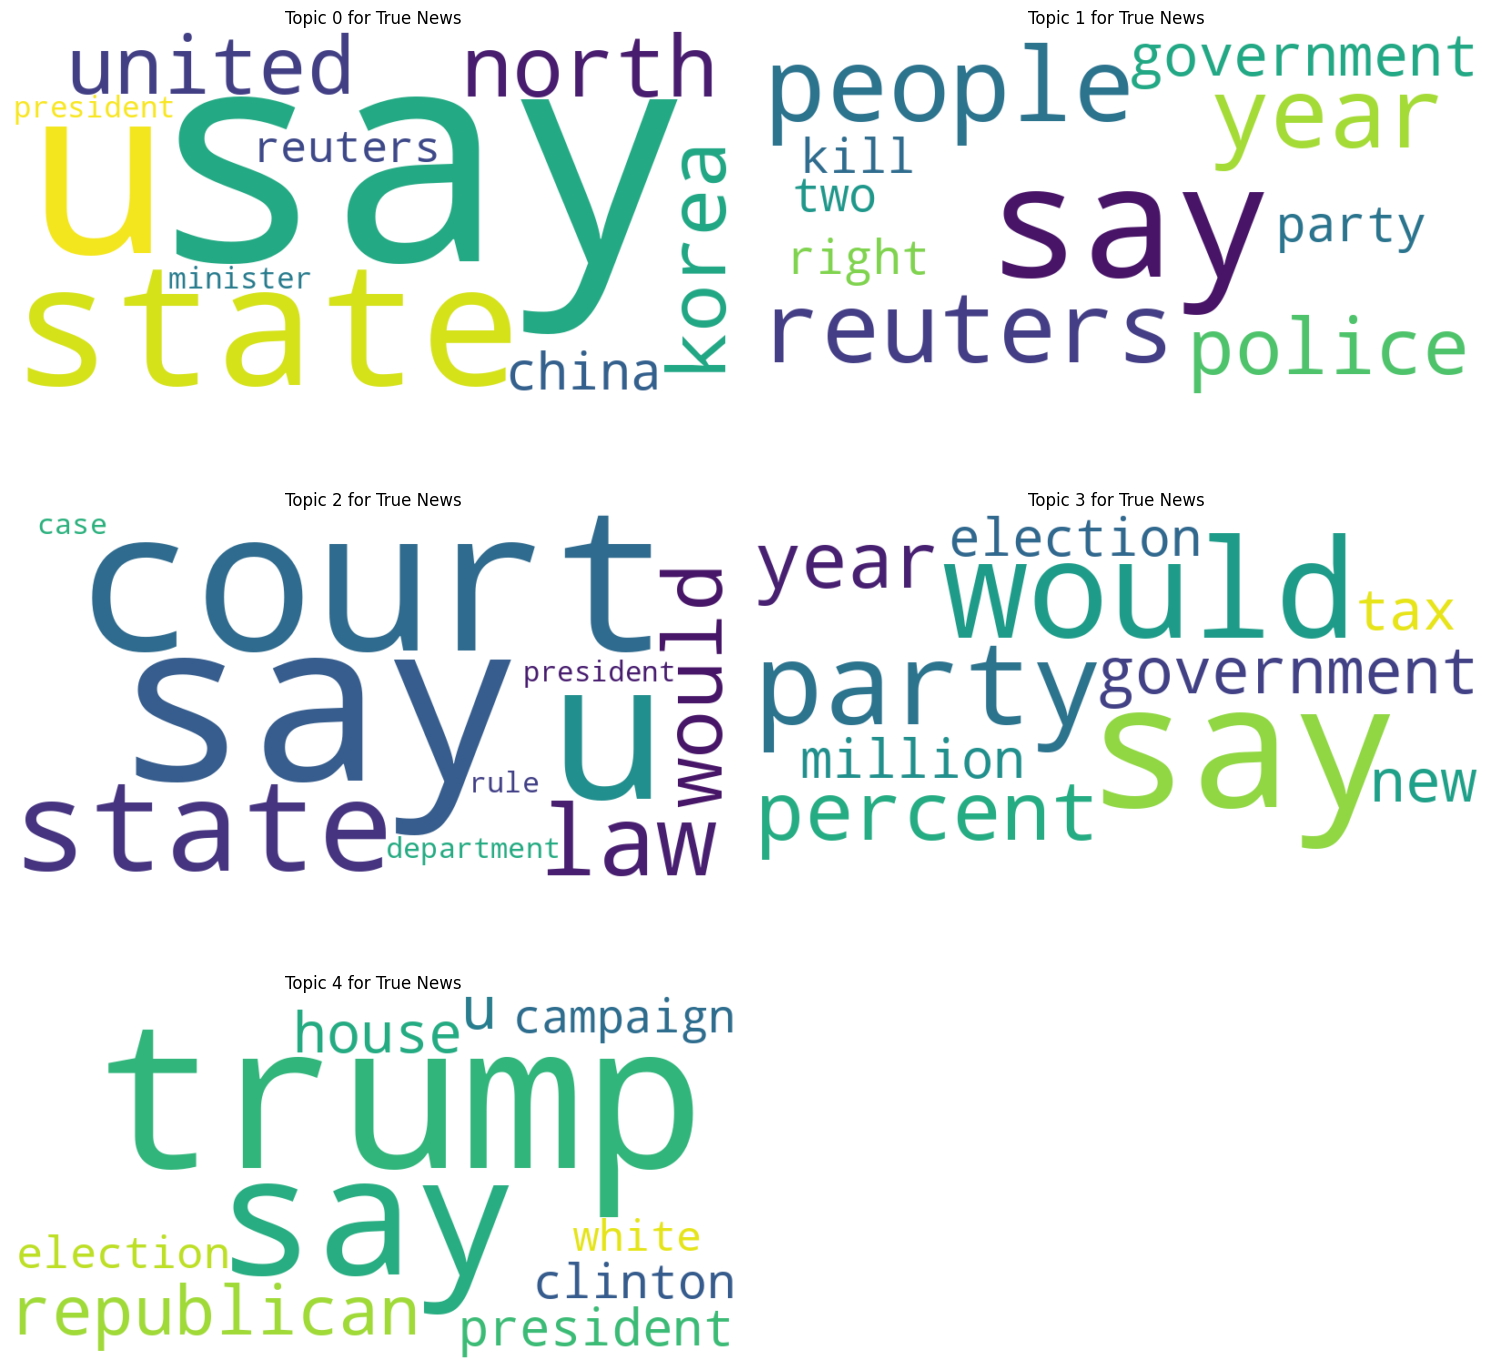


Generating word clouds for Fake News topics...


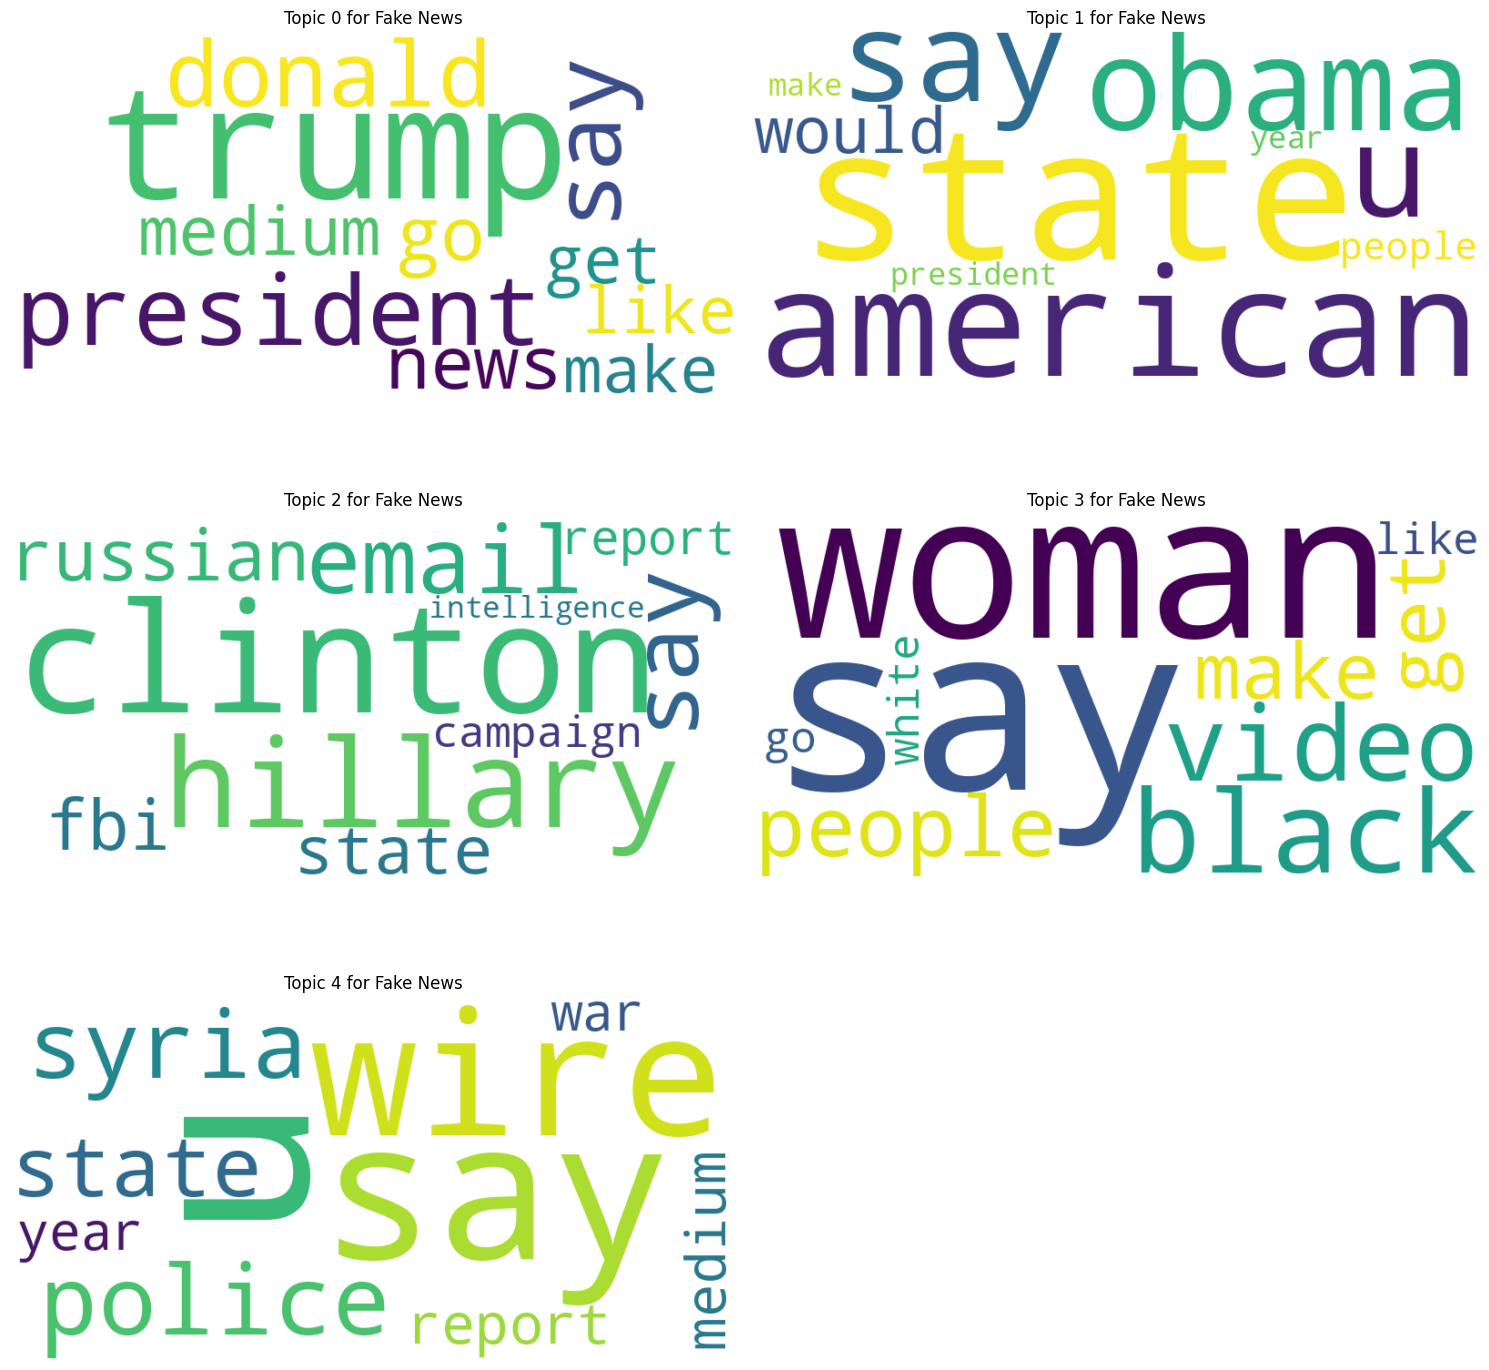

Word cloud generation complete.


In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to create and display word clouds for each topic
def plot_word_clouds(lda_model, num_topics, id2word, title_prefix):
    cols = 2 # Number of columns for subplots
    rows = (num_topics + cols - 1) // cols # Calculate rows needed
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if rows > 1 or cols > 1 else [axes]

    for i, topic in lda_model.show_topics(num_topics=num_topics, formatted=False):
        topic_words = dict(topic)
        wordcloud = WordCloud(width=800, height=400,
                              background_color='white',
                              collocations=False,
                              min_font_size=10).generate_from_frequencies(topic_words)

        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f'Topic {i} for {title_prefix}', fontsize=12)
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(num_topics, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Plot word clouds for True News topics
print("Generating word clouds for True News topics...")
plot_word_clouds(lda_model_true, num_topics, id2word_true, 'True News')

# Plot word clouds for Fake News topics
print("\nGenerating word clouds for Fake News topics...")
plot_word_clouds(lda_model_fake, num_topics, id2word_fake, 'Fake News')

print("Word cloud generation complete.")

Addestramento del modello TF-IDF.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. Concatenate the 'processed_text' columns
combined_processed_text = pd.concat([df_true_news['processed_text'], df_fake_news['processed_text']], ignore_index=True)
print(f"Shape of combined_processed_text: {combined_processed_text.shape}")

# 2. Initialize and apply TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10000) # Limiting max_features for performance
tfidf_features = tfidf_vectorizer.fit_transform(combined_processed_text)
print(f"Shape of TF-IDF features: {tfidf_features.shape}")

# Display some information about the TF-IDF features
print("\nFirst 5 TF-IDF features for the first document (non-zero values):")
print(tfidf_features[0].nonzero()[1][:5])
print(tfidf_features[0].data[:5])

Shape of combined_processed_text: (44898,)
Shape of TF-IDF features: (44898, 10000)

First 5 TF-IDF features for the first document (non-zero values):
[1170 3372 5268 7480 3455]
[0.19624609 0.04977533 0.0495294  0.25084534 0.04648277]


Qui prepariamo i dati TF-IDF per l'addestramento e la valutazione del modello. Per prima cosa, concateniamo le etichette originali (`label`) delle notizie vere e false. Successivamente, utilizziamo `train_test_split` per dividere le feature TF-IDF (`tfidf_features`) e le etichette combinate (`labels`) in set di training e testing. La divisione è impostata al 25% per il test set e viene stratificata per mantenere la proporzione di notizie vere e false in entrambi i set.

In [16]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 3. Prepare the labels
labels = pd.concat([df_true_news['label'], df_fake_news['label']], ignore_index=True)
print(f"Shape of labels: {labels.shape}")

# 4. Split the TF-IDF features and labels into training and testing sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(tfidf_features, labels, test_size=0.25, random_state=42, stratify=labels)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of labels: (44898,)
Shape of X_train_tfidf: (33673, 10000)
Shape of X_test_tfidf: (11225, 10000)
Shape of y_train: (33673,)
Shape of y_test: (11225,)


Addestriamo un modello Word2Vec. Il modello addestrato viene salvato e vengono visualizzate alcune informazioni, inclusa la dimensione del vocabolario e un esempio di embedding per la parola 'trump'.

In [17]:
import gensim
from gensim.models import Word2Vec

# 5. Tokenize the combined processed text for Word2Vec training
# This assumes combined_processed_text is a pandas Series of strings
sentences = [doc.split() for doc in combined_processed_text]
print(f"Tokenized {len(sentences)} documents for Word2Vec training.")

# Train a Word2Vec model
# You can adjust parameters like vector_size, window, min_count, workers, etc.
# For a pre-trained model, you would load it here instead of training.
print("Training Word2Vec model...")
word2vec_model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=5, workers=4, sg=0) # sg=0 for CBOW
print("Word2Vec model training complete.")

# Save the trained model (optional, but good practice)
word2vec_model.save("word2vec_model.bin")
print("Word2Vec model saved to word2vec_model.bin")

# Display some information about the model
print(f"\nWord2Vec model vocabulary size: {len(word2vec_model.wv)}")
print(f"Example word embedding for 'trump': {word2vec_model.wv['trump'][:5]}")


Tokenized 44898 documents for Word2Vec training.
Training Word2Vec model...
Word2Vec model training complete.
Word2Vec model saved to word2vec_model.bin

Word2Vec model vocabulary size: 36944
Example word embedding for 'trump': [-0.96463776 -2.4366157  -0.26070353  2.2960749   2.8822706 ]


Questa cella definisce la funzione `document_vector`, essenziale per la creazione degli *embedding* dei documenti. Questa funzione prende un modello Word2Vec e una lista di parole (un documento), filtra le parole non presenti nel vocabolario del modello e calcola la media dei vettori di *embedding* delle parole rimanenti. Se non ci sono parole riconosciute, restituisce un vettore nullo. Viene mostrato un esempio di utilizzo per dimostrarne il funzionamento.

In [18]:
import numpy as np

# 6. Function to average word embeddings for document embedding
def document_vector(word2vec_model, words):
    # Filter out words that are not in the model's vocabulary
    words = [word for word in words if word in word2vec_model.wv]
    if not words:
        # Return a zero vector if no words are found in the vocabulary
        return np.zeros(word2vec_model.vector_size)
    # Average the embeddings of the remaining words
    return np.mean(word2vec_model.wv[words], axis=0)

print("Defined document_vector function.")

# Example usage:
example_text = "trump administration said today".split()
example_vec = document_vector(word2vec_model, example_text)
print(f"\nExample document vector shape: {example_vec.shape}")
print(f"Example document vector (first 5 elements): {example_vec[:5]}")

Defined document_vector function.

Example document vector shape: (100,)
Example document vector (first 5 elements): [-0.60355073 -1.7068402  -0.4298773   1.4827706   0.7349213 ]


Questa cella applica la funzione `document_vector` definita precedentemente a tutto il testo pre-elaborato combinato (`combined_processed_text`). Per ogni documento, viene generato un unico vettore di *embedding* che rappresenta l'intero documento. Il risultato è un array NumPy chiamato `document_embeddings`, che contiene i vettori di tutti i documenti. Viene stampata la forma dell'array e i primi elementi del primo *embedding* per verifica.

In [19]:
import numpy as np

# 7. Apply the function to combined_processed_text to generate document embeddings
print("Generating document embeddings for all processed texts...")
document_embeddings = np.array([document_vector(word2vec_model, doc.split()) for doc in combined_processed_text])
print("Document embeddings generation complete.")

print(f"Shape of document_embeddings: {document_embeddings.shape}")
print(f"First document embedding (first 5 elements): {document_embeddings[0][:5]}")

Generating document embeddings for all processed texts...
Document embeddings generation complete.
Shape of document_embeddings: (44898, 100)
First document embedding (first 5 elements): [-0.1346623  -0.6530352  -0.257427   -0.04009857  0.068798  ]


In questa cella, dividiamo i vettori di *embedding* dei documenti (`document_embeddings`) e le etichette corrispondenti (`labels`) in set di training e testing. Anche in questo caso, utilizziamo `train_test_split` con una proporzione del 25% per il test set e la stratificazione per mantenere l'equilibrio delle classi. Questo prepara i dati per l'addestramento e la valutazione dei modelli che utilizzeranno gli *embedding* Word2Vec.

In [20]:
from sklearn.model_selection import train_test_split

# 8. Split the document embeddings and labels into training and testing sets
# The 'labels' variable was already created and is consistent with the order of document_embeddings
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(document_embeddings, labels, test_size=0.25, random_state=42, stratify=labels)

print(f"Shape of X_train_w2v: {X_train_w2v.shape}")
print(f"Shape of X_test_w2v: {X_test_w2v.shape}")
print(f"Shape of y_train_w2v: {y_train_w2v.shape}")
print(f"Shape of y_test_w2v: {y_test_w2v.shape}")

Shape of X_train_w2v: (33673, 100)
Shape of X_test_w2v: (11225, 100)
Shape of y_train_w2v: (33673,)
Shape of y_test_w2v: (11225,)


Questa sezione addestra due modelli di Regressione Logistica. Il primo, `log_reg_tfidf`, viene addestrato sulle feature TF-IDF (`X_train_tfidf`) e le etichette (`y_train`). Il secondo, `log_reg_w2v`, viene addestrato sulle feature basate su Word2Vec (`X_train_w2v`) e le etichette (`y_train_w2v`). Entrambi i modelli sono configurati con `random_state=42` e `max_iter=1000` per garantire riproducibilità e convergenza.

In [21]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize a LogisticRegression model for TF-IDF features
print("Initializing and training Logistic Regression model with TF-IDF features...")
log_reg_tfidf = LogisticRegression(random_state=42, max_iter=1000)

# 2. Train the TF-IDF-based Logistic Regression model
log_reg_tfidf.fit(X_train_tfidf, y_train)
print("Logistic Regression model with TF-IDF features trained.")

# 3. Initialize another LogisticRegression model for Word2Vec features
print("\nInitializing and training Logistic Regression model with Word2Vec features...")
log_reg_w2v = LogisticRegression(random_state=42, max_iter=1000)

# 4. Train the Word2Vec-based Logistic Regression model
log_reg_w2v.fit(X_train_w2v, y_train_w2v)
print("Logistic Regression model with Word2Vec features trained.")

print("Trained Logistic Regression models for TF-IDF and Word2Vec features have been stored.")

Initializing and training Logistic Regression model with TF-IDF features...
Logistic Regression model with TF-IDF features trained.

Initializing and training Logistic Regression model with Word2Vec features...
Logistic Regression model with Word2Vec features trained.
Trained Logistic Regression models for TF-IDF and Word2Vec features have been stored.


Questa cella valuta le prestazioni dei modelli di Regressione Logistica addestrati, sia quello basato su TF-IDF che quello basato su Word2Vec. Per ciascun modello, vengono calcolate metriche come accuratezza, precisione, recall e F1-score utilizzando i rispettivi set di test. Viene anche generato e stampato un *classification report* dettagliato. Infine, viene visualizzata una *confusion matrix* per ciascun modello.


--- Evaluation for TF-IDF based Logistic Regression Model ---
Accuracy (TF-IDF): 0.9858
Precision (TF-IDF): 0.9882
Recall (TF-IDF): 0.9847
F1-Score (TF-IDF): 0.9864

Classification Report (TF-IDF):

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5354
           1       0.99      0.98      0.99      5871

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



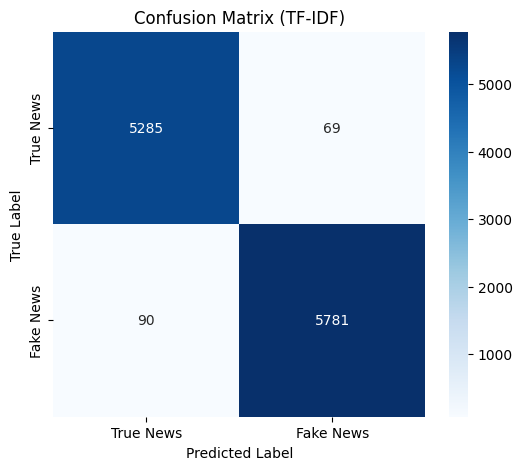


--- Evaluation for Word2Vec based Logistic Regression Model ---
Accuracy (Word2Vec): 0.9574
Precision (Word2Vec): 0.9618
Recall (Word2Vec): 0.9566
F1-Score (Word2Vec): 0.9592

Classification Report (Word2Vec):

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      5354
           1       0.96      0.96      0.96      5871

    accuracy                           0.96     11225
   macro avg       0.96      0.96      0.96     11225
weighted avg       0.96      0.96      0.96     11225



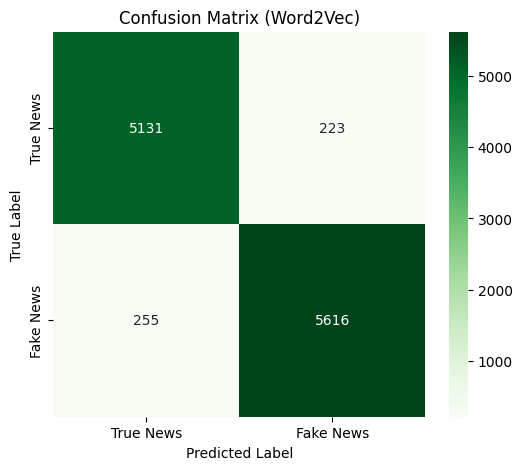

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluation for TF-IDF based model ---
print("\n--- Evaluation for TF-IDF based Logistic Regression Model ---")

# Make predictions on the test set
y_pred_tfidf = log_reg_tfidf.predict(X_test_tfidf)

# Calculate metrics
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
precision_tfidf = precision_score(y_test, y_pred_tfidf)
recall_tfidf = recall_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf)

print(f"Accuracy (TF-IDF): {accuracy_tfidf:.4f}")
print(f"Precision (TF-IDF): {precision_tfidf:.4f}")
print(f"Recall (TF-IDF): {recall_tfidf:.4f}")
print(f"F1-Score (TF-IDF): {f1_tfidf:.4f}")

# Print classification report
print("\nClassification Report (TF-IDF):\n")
print(classification_report(y_test, y_pred_tfidf))

# Generate and plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_tfidf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['True News', 'Fake News'], yticklabels=['True News', 'Fake News'])
plt.title('Confusion Matrix (TF-IDF)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Evaluation for Word2Vec based model ---
print("\n--- Evaluation for Word2Vec based Logistic Regression Model ---")

# Make predictions on the test set
y_pred_w2v = log_reg_w2v.predict(X_test_w2v)

# Calculate metrics
accuracy_w2v = accuracy_score(y_test_w2v, y_pred_w2v)
precision_w2v = precision_score(y_test_w2v, y_pred_w2v)
recall_w2v = recall_score(y_test_w2v, y_pred_w2v)
f1_w2v = f1_score(y_test_w2v, y_pred_w2v)

print(f"Accuracy (Word2Vec): {accuracy_w2v:.4f}")
print(f"Precision (Word2Vec): {precision_w2v:.4f}")
print(f"Recall (Word2Vec): {recall_w2v:.4f}")
print(f"F1-Score (Word2Vec): {f1_w2v:.4f}")

# Print classification report
print("\nClassification Report (Word2Vec):\n")
print(classification_report(y_test_w2v, y_pred_w2v))

# Generate and plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_w2v, y_pred_w2v), annot=True, fmt='d', cmap='Greens',
            xticklabels=['True News', 'Fake News'], yticklabels=['True News', 'Fake News'])
plt.title('Confusion Matrix (Word2Vec)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Questa cella importa le librerie necessarie per l'ottimizzazione del modello. In particolare, vengono importate `GridSearchCV` dal modulo `sklearn.model_selection`, utilizzata per la *tuning* degli iperparametri tramite ricerca a griglia e *cross-validation*, e `LogisticRegression` dal modulo `sklearn.linear_model`, il tipo di modello che intendiamo ottimizzare.

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

print("Imported GridSearchCV and LogisticRegression.")

Imported GridSearchCV and LogisticRegression.


In questa cella, ottimizziamo il modello di Regressione Logistica basato su TF-IDF tramite *Grid Search Cross-Validation*. Definiamo una griglia di iperparametri (`param_grid`) da esplorare, inclusi il parametro di regolarizzazione `C` e il tipo di penalità (`l1` o `l2`).

In [24]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize LogisticRegression model
log_reg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Initialize GridSearchCV
print("Initializing GridSearchCV...")
grid_search_tfidf = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
print("GridSearchCV initialized.")

# Fit GridSearchCV to the TF-IDF training data
print("Fitting GridSearchCV to TF-IDF training data...")
grid_search_tfidf.fit(X_train_tfidf, y_train)
print("GridSearchCV fitting complete.")

# Print best parameters and best score (instructions 5 and 6)
print(f"\nBest parameters for TF-IDF: {grid_search_tfidf.best_params_}")
print(f"Best cross-validation F1-score for TF-IDF: {grid_search_tfidf.best_score_:.4f}")

# Store the best estimator (instruction 7)
best_log_reg_tfidf = grid_search_tfidf.best_estimator_
print("Best Logistic Regression model for TF-IDF stored.")

Initializing GridSearchCV...
GridSearchCV initialized.
Fitting GridSearchCV to TF-IDF training data...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV fitting complete.

Best parameters for TF-IDF: {'C': 10, 'penalty': 'l1'}
Best cross-validation F1-score for TF-IDF: 0.9956
Best Logistic Regression model for TF-IDF stored.


Questa cella definisce la funzione `classify_news_tfidf`, che permette di classificare un nuovo articolo di notizie utilizzando il modello ottimizzato basato su TF-IDF. La funzione prende il testo grezzo dell'articolo, lo pre-elabora usando la funzione `preprocess_text`, lo trasforma in un vettore TF-IDF utilizzando il `tfidf_vectorizer` addestrato e infine utilizza il `best_log_reg_tfidf` per fare una previsione, restituendo 'True News' o 'Fake News'.

In [25]:
def classify_news_tfidf(raw_news_text):
    # Preprocess the raw text
    processed_text = preprocess_text(raw_news_text)

    # Transform the processed text using the fitted TF-IDF vectorizer
    # The vectorizer expects an iterable, so pass it as a list
    tfidf_vector = tfidf_vectorizer.transform([processed_text])

    # Make prediction using the best TF-IDF model
    prediction = best_log_reg_tfidf.predict(tfidf_vector)

    # Return human-readable label
    return 'True News' if prediction[0] == 0 else 'Fake News'

print("TF-IDF news classification function defined.")

TF-IDF news classification function defined.


Questa cella definisce la funzione `classify_news_w2v`, simile alla precedente ma per il modello ottimizzato basato su Word2Vec. Prende il testo grezzo, lo pre-elabora con `preprocess_text`, lo converte in un *document embedding* utilizzando la funzione `document_vector` e il `word2vec_model` addestrato. Il vettore del documento viene quindi ri-modellato per l'input del modello e usato da `best_log_reg_w2v` per prevedere se l'articolo è 'True News' o 'Fake News'.

In [26]:
def classify_news_w2v(raw_news_text):
    # Preprocess the raw text
    processed_text = preprocess_text(raw_news_text)

    # Convert processed text to a document vector using Word2Vec model
    # The document_vector function expects a list of words
    doc_vector = document_vector(word2vec_model, processed_text.split())

    # Reshape for single sample prediction
    doc_vector = doc_vector.reshape(1, -1)

    # Make prediction using the best Word2Vec model
    prediction = best_log_reg_w2v.predict(doc_vector)

    # Return human-readable label
    return 'True News' if prediction[0] == 0 else 'Fake News'

print("Word2Vec news classification function defined.")

Word2Vec news classification function defined.


Questa cella esegue l'ottimizzazione degli iperparametri per il modello di Regressione Logistica basato su Word2Vec, utilizzando `GridSearchCV`. Similmente a quanto fatto per il modello TF-IDF, viene definita una griglia di iperparametri (`param_grid_w2v`) per `C` e `penalty`. `GridSearchCV` viene inizializzato con il modello e la griglia, quindi addestrato sui dati di training Word2Vec (`X_train_w2v`, `y_train_w2v`). Infine, vengono stampati i migliori parametri e il punteggio F1 di cross-validation, e il modello ottimizzato viene memorizzato in `best_log_reg_w2v`.

In [27]:
param_grid_w2v = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize LogisticRegression model for Word2Vec
log_reg_w2v_tune = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Initialize GridSearchCV for Word2Vec
print("\nInitializing GridSearchCV for Word2Vec features...")
grid_search_w2v = GridSearchCV(estimator=log_reg_w2v_tune, param_grid=param_grid_w2v, cv=5, scoring='f1', verbose=1, n_jobs=-1)
print("GridSearchCV for Word2Vec initialized.")

# Fit GridSearchCV to the Word2Vec training data
print("Fitting GridSearchCV to Word2Vec training data...")
grid_search_w2v.fit(X_train_w2v, y_train_w2v)
print("GridSearchCV for Word2Vec fitting complete.")

# Print best parameters and best score
print(f"\nBest parameters for Word2Vec: {grid_search_w2v.best_params_}")
print(f"Best cross-validation F1-score for Word2Vec: {grid_search_w2v.best_score_:.4f}")

# Store the best estimator
best_log_reg_w2v = grid_search_w2v.best_estimator_
print("Best Logistic Regression model for Word2Vec stored.")


Initializing GridSearchCV for Word2Vec features...
GridSearchCV for Word2Vec initialized.
Fitting GridSearchCV to Word2Vec training data...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV for Word2Vec fitting complete.

Best parameters for Word2Vec: {'C': 100, 'penalty': 'l1'}
Best cross-validation F1-score for Word2Vec: 0.9609
Best Logistic Regression model for Word2Vec stored.


In questa cella, testiamo le funzioni di classificazione `classify_news_tfidf` e `classify_news_w2v` con esempi concreti.

In [29]:

preprocess_text = preprocess_text_fast_pos

# You can also try your own news article here
my_custom_news = "Trump is an alien"
print("\n--- Classifying Your Custom News ---")
print(f"TF-IDF Model Prediction: {classify_news_tfidf(my_custom_news)}")
print(f"Word2Vec Model Prediction: {classify_news_w2v(my_custom_news)}")


--- Classifying Your Custom News ---
TF-IDF Model Prediction: Fake News
Word2Vec Model Prediction: Fake News
